## 1. IMPORT LIBARARIES  
POWER_PLANT DATASET 
PERFORMING ANN REGRESSION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("powerPlant.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


## 2. EDA(EXPLORARTORY DATA ANALYSIS)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(41)

In [6]:
df.shape

(9568, 5)

In [7]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


## 3. Target Value Selection

In [8]:
X = df.drop("PE", axis = 1)
y = df["PE"]

In [9]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [10]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

## 4. Model Selection

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2, random_state = 42
)

In [12]:
X_train.head()

,AT,V,AP,RH
5487,25.24,63.47,1011.30,66.21
3522,26.09,70.40,1007.41,85.37
6916,26.63,73.68,1015.15,85.13
7544,32.06,71.85,1007.90,56.44
7600,28.70,71.64,1007.11,69.85


In [13]:
y_train.head()

5487    442.75
3522    432.52
6916    428.80
7544    426.07
7600    436.58
Name: PE, dtype: float64

## 5. StandardScaler Preprocessing

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [16]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

## 6. Load Data_set into Tensor

In [17]:
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)

In [18]:
y_train.shape

(7654,)

## 7. TensorDataset To Create DataLoader

In [19]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor )

In [20]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32)

## 8. Start Deep Learning Part
Build Our ANN Module

In [21]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # First Hidden Layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # Second Hidden Layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # Output Layer
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

In [28]:
model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

## 9. Training The ANN Model (Artificial Neural Network)

In [23]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 205852.387890625 & val loss = 204386.046875
epoch 2/100 ==> train loss = 200396.63131510417 & val loss = 193360.65625
epoch 3/100 ==> train loss = 179845.15989583332 & val loss = 162549.0625
epoch 4/100 ==> train loss = 139898.50709635418 & val loss = 115474.28125
epoch 5/100 ==> train loss = 91099.67150065103 & val loss = 68387.546875
epoch 6/100 ==> train loss = 51109.63434244792 & val loss = 37353.59765625
epoch 7/100 ==> train loss = 29402.305025227866 & val loss = 23895.96875
epoch 8/100 ==> train loss = 20998.263452148436 & val loss = 18725.8203125
epoch 9/100 ==> train loss = 17201.282845052083 & val loss = 15635.7783203125
epoch 10/100 ==> train loss = 14378.050612386067 & val loss = 12941.982421875
epoch 11/100 ==> train loss = 11782.31596883138 & val loss = 10371.958984375
epoch 12/100 ==> train loss = 9289.123057047525 & val loss = 7970.07177734375
epoch 13/100 ==> train loss = 6989.666310628255 & val loss = 5801.724609375
epoch 14/100 ==> train 

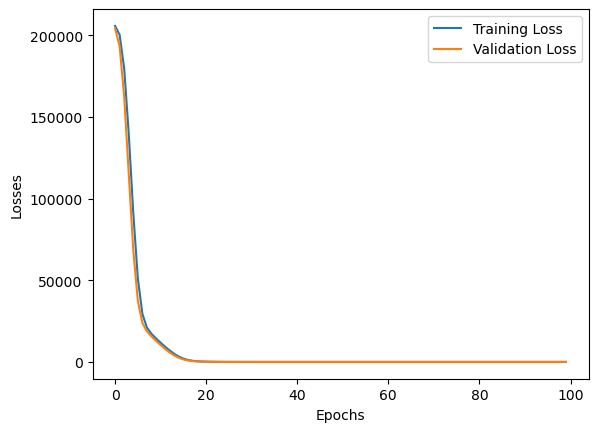

In [29]:
loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})
plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()
plt.show()

In [30]:
#Loding the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [32]:
#Evaluation
model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = crietrion(train_pred, y_train_tensor)
    test_mse_loss = crietrion(test_pred, y_test_tensor)

print("Training MSE loss",train_mse_loss.item())
print("Testing MSE loss", test_mse_loss.item())

Training MSE loss 20.504594802856445
Testing MSE loss 18.82399559020996


In [35]:
print("r2_score value:", r2_score(y_test,test_pred)*100)

r2_score value: 93.42149937507415


In [34]:
predicted_df = pd.DataFrame(test_pred.numpy(),columns= ["predicted_values"])
actual_df = pd.DataFrame(y_test.values,columns=["Actual_Values"])

pd.concat([predicted_df,actual_df], axis = 1)

,predicted_values,Actual_Values
0,435.095978,433.27
1,436.584259,438.16
2,461.791290,458.42
3,476.618134,480.82
4,435.822174,441.41
...,...,...
1909,450.930267,456.70
1910,431.359619,438.04
1911,467.592621,467.80
1912,430.839050,437.14
